In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


def set_plot_style():
    """A clean, paper-like matplotlib style (Nature-ish)."""

    palette = [
        "#1F77B4",
        "#FF7F0E",
        "#2CA02C",
        "#D62728",
        "#9467BD",
        "#8C564B",
        "#E377C2",
        "#7F7F7F",
        "#BCBD22",
        "#17BECF",
    ]

    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "DejaVu Sans"],
            "svg.fonttype": "none",
            "font.size": 13,
            "axes.spines.right": False,
            "axes.spines.top": False,
            "axes.linewidth": 1.5,
            "axes.grid": False,
            "axes.prop_cycle": plt.cycler(color=palette),
            "xtick.direction": "out",
            "ytick.direction": "out",
            "xtick.major.size": 4,
            "ytick.major.size": 4,
            "lines.linewidth": 2.0,
            "lines.markersize": 5,
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
        }
    )


set_plot_style()

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
try:
    torch.set_num_threads(1)
except Exception:
    pass

print(f"PyTorch version: {torch.__version__}")
print(f"Default device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.6.0+cu124
Default device: cuda


## 2 概述、线性代数和 NDArray
## 2.1 理论计算题

已知向量 $\mathbf{a}=[2,-1,3]^\top$，$\mathbf{b}=[1,4,-2]^\top$，

$$
A=\begin{bmatrix}1&0&2\\-1&3&1\end{bmatrix},\qquad
B=\begin{bmatrix}2&1\\0&-1\\3&2\end{bmatrix}.
$$

1) 点积：
$$
\mathbf{a}\cdot\mathbf{b}=2\cdot 1+(-1)\cdot 4+3\cdot(-2)=2-4-6=\boxed{-8}.
$$

2) 乘法 $A\times B$：$A\in\mathbb{R}^{2\times 3}$，$B\in\mathbb{R}^{3\times 2}$，所以结果形状为 $\boxed{2\times 2}$。

3) Frobenius 范数（向量即 $\ell_2$ 范数）：
$$
\|\mathbf{a}\|_F=\sqrt{2^2+(-1)^2+3^2}=\sqrt{14}.
$$

In [2]:
import numpy as np

a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2], [-1, 3, 1]])
B = np.array([[2, 1], [0, -1], [3, 2]])

dot_product = np.dot(a, b)
matrix_multiplication = A @ B
fro_norm = np.linalg.norm(a)

print('向量点积 a · b:', dot_product)
print('矩阵乘法 A × B (shape={}):\n{}'.format(matrix_multiplication.shape, matrix_multiplication))
print('向量 a 的 Frobenius 范数:', fro_norm)

向量点积 a · b: -8
矩阵乘法 A × B (shape=(2, 2)):
[[ 8  5]
 [ 1 -2]]
向量 a 的 Frobenius 范数: 3.7416573867739413


## 2.2 编程题

1) 创建 $3\times 4$ 的随机矩阵 $X$（标准正态）。
2) 创建 $4\times 2$ 的全 1 矩阵 $Y$。
3) 计算 $Z=X\times Y$。
4) 输出 $Z$ 的 (第 1 行, 第 2 列) 元素，以及第 2 行所有元素。
5) 计算 $Z$ 的 Frobenius 范数。

In [3]:
X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y

print('X shape:', X.shape)
print('Y shape:', Y.shape)
print('Z shape:', Z.shape)
print('Z[0, 1] (第一行第二列):', Z[0, 1])
print('Z[1, :] (第二行所有元素):', Z[1, :])
print('Z 的 Frobenius 范数:', np.linalg.norm(Z))

X shape: (3, 4)
Y shape: (4, 2)
Z shape: (3, 2)
Z[0, 1] (第一行第二列): -1.5262567005491967
Z[1, :] (第二行所有元素): [-0.67819409 -0.67819409]
Z 的 Frobenius 范数: 2.4244631705722406


## 3 概率与统计
## 3.1 理论计算题（贝叶斯公式）

设事件 $D$ 表示“患病”，$+$ 表示“检测阳性”。

- 患病率：$P(D)=0.001$，$P(\bar D)=0.999$
- 灵敏度：$P(+|D)=0.99$
- 假阳性率：$P(+|\bar D)=0.02$

由贝叶斯公式：

$$
P(D|+)=\frac{P(+|D)P(D)}{P(+|D)P(D)+P(+|\bar D)P(\bar D)}
=\frac{0.99\cdot 0.001}{0.99\cdot 0.001+0.02\cdot 0.999}.
$$

数值结果约为 $\boxed{4.72\%}$（远低于 99%，原因是基准患病率很低）。

In [4]:
P_D = 0.001
P_notD = 1 - P_D
P_pos_given_D = 0.99
P_pos_given_notD = 0.02

P_D_given_pos = (P_pos_given_D * P_D) / (P_pos_given_D * P_D + P_pos_given_notD * P_notD)
print('P(D | +) =', P_D_given_pos)
print('P(D | +) (%) = {:.2f}%'.format(P_D_given_pos * 100))

P(D | +) = 0.047210300429184546
P(D | +) (%) = 4.72%


## 3.2 编程题（中心极限定理模拟）

生成 $m=1000$ 次实验：每次采样 $n=10000$ 个 $U(0,1)$ 随机变量并求均值。
绘制均值的直方图，并叠加理论正态分布密度曲线；同时计算这些均值的实际方差。

提示：若 $X\sim U(0,1)$，则 $\mathbb{E}[X]=1/2$，$\mathrm{Var}(X)=1/12$，均值的方差为 $\mathrm{Var}(\bar X)=\frac{1}{12n}$。

样本均值的实际方差: 7.96012127290918e-06
理论方差 1/(12n): 8.333333333333334e-06


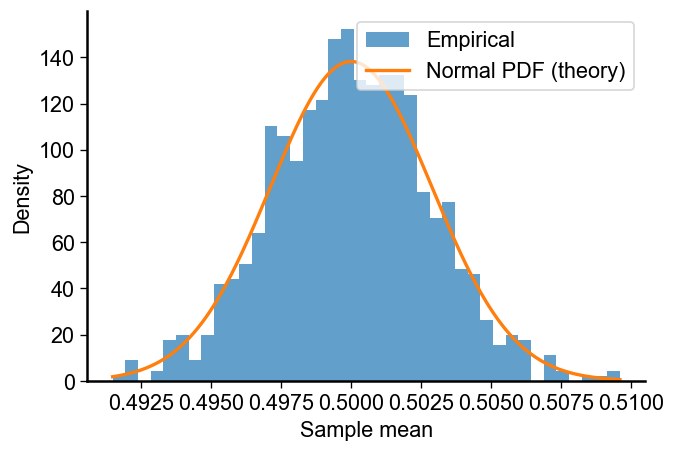

In [5]:
n = 10000
m = 1000

means = np.mean(np.random.rand(m, n), axis=1)
mu = 0.5
sigma2 = 1 / (12 * n)
sigma = math.sqrt(sigma2)

print('样本均值的实际方差:', np.var(means))
print('理论方差 1/(12n):', sigma2)

xs = np.linspace(means.min(), means.max(), 400)
pdf = (1 / (sigma * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)

plt.figure(figsize=(6, 4))
plt.hist(means, bins=40, density=True, alpha=0.7, label='Empirical')
plt.plot(xs, pdf, label='Normal PDF (theory)')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.show()

## 4 导数、反向传播和复杂度
## 4.1 理论计算题

给定
$$
z=(w_1x_1+w_2x_2-y)^2,\qquad x_1=2,\;x_2=1,\;y=3.
$$
令 $e=w_1x_1+w_2x_2-y$，则 $z=e^2$，
$$
\frac{\partial z}{\partial w_1}=2e\cdot x_1,\qquad
\frac{\partial z}{\partial w_2}=2e\cdot x_2.
$$
当 $w_1=0.5,\;w_2=1$ 时，
$$
e=0.5\cdot 2+1\cdot 1-3=1+1-3=-1,
$$
所以
$$
\boxed{\frac{\partial z}{\partial w_1}=-4},\qquad\boxed{\frac{\partial z}{\partial w_2}=-2}.
$$

## 4.2 编程题（手动反向传播 + autograd 验证）

计算图：
$$
a=x\cdot w_1,\quad b=a+w_2,\quad L=b^2.
$$
给定 $x=2,\;w_1=1.5,\;w_2=0.5$，手动按链式法则计算 $\partial L/\partial w_1$ 与 $\partial L/\partial w_2$，并用 `torch.autograd` 验证。

In [6]:
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b**2

# 手动反传
dL_db = 2 * b
db_da = 1.0
db_dw2 = 1.0
da_dw1 = x

dL_dw2_manual = dL_db * db_dw2
dL_dw1_manual = dL_db * db_da * da_dw1

print('Forward: a=', a, 'b=', b, 'L=', L)
print('Manual grads: dL/dw1=', dL_dw1_manual, 'dL/dw2=', dL_dw2_manual)

# autograd 验证
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
x_t = torch.tensor(x)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t**2
L_t.backward()

print('Autograd grads: dL/dw1=', w1_t.grad.item(), 'dL/dw2=', w2_t.grad.item())
print('Allclose:', np.allclose([dL_dw1_manual, dL_dw2_manual], [w1_t.grad.item(), w2_t.grad.item()]))

Forward: a= 3.0 b= 3.5 L= 12.25
Manual grads: dL/dw1= 14.0 dL/dw2= 7.0
Autograd grads: dL/dw1= 14.0 dL/dw2= 7.0
Allclose: True


## 5 线性方法、基础优化和 Softmax 回归
## 5.1 理论计算题

线性回归模型 $\hat y_i=wx_i+b$，均方误差损失
$$
L=\frac{1}{n}\sum_{i=1}^n\left(y_i-(wx_i+b)\right)^2.
$$
记误差 $e_i=y_i-(wx_i+b)$，则
$$
\frac{\partial L}{\partial w}=\frac{1}{n}\sum_{i=1}^n 2e_i\cdot\frac{\partial e_i}{\partial w}
=\frac{1}{n}\sum_{i=1}^n 2\left(y_i-(wx_i+b)\right)\cdot(-x_i)
=\boxed{-\frac{2}{n}\sum_{i=1}^n x_i\left(y_i-(wx_i+b)\right)}.
$$
$$
\frac{\partial L}{\partial b}=\frac{1}{n}\sum_{i=1}^n 2\left(y_i-(wx_i+b)\right)\cdot(-1)
=\boxed{-\frac{2}{n}\sum_{i=1}^n \left(y_i-(wx_i+b)\right)}.
$$

## 5.2 编程题（从零实现 Softmax 回归分类）

使用 `sklearn.datasets.load_digits()`（8×8 灰度数字）完成：
- 展平为向量并做 one-hot
- 实现 softmax 与交叉熵
- 小批量 SGD：batch=32，lr=0.1，训练 50 epoch
- 输出测试集准确率

In [7]:
def one_hot(y, num_classes):
    Y = np.zeros((y.size, num_classes), dtype=np.float32)
    Y[np.arange(y.size), y] = 1.0
    return Y


def softmax(logits):
    # logits: (N, K)
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


def cross_entropy(probs, y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))


digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)
K = 10

# 简单归一化到 [0,1]
X = X / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
Y_train = one_hot(y_train, K)
Y_test = one_hot(y_test, K)

N, D = X_train.shape
W = 0.01 * np.random.randn(D, K).astype(np.float32)
b = np.zeros((1, K), dtype=np.float32)

batch_size = 32
lr = 0.1
epochs = 50

for epoch in range(1, epochs + 1):
    idx = np.random.permutation(N)
    X_shuf = X_train[idx]
    Y_shuf = Y_train[idx]

    for i in range(0, N, batch_size):
        xb = X_shuf[i : i + batch_size]
        yb = Y_shuf[i : i + batch_size]
        logits = xb @ W + b
        probs = softmax(logits)
        # dL/dlogits = (probs - y_onehot)/B
        B = xb.shape[0]
        dlogits = (probs - yb) / B
        dW = xb.T @ dlogits
        db = np.sum(dlogits, axis=0, keepdims=True)
        W -= lr * dW
        b -= lr * db

    if epoch % 10 == 0 or epoch == 1:
        train_probs = softmax(X_train @ W + b)
        train_loss = cross_entropy(train_probs, Y_train)
        train_pred = np.argmax(train_probs, axis=1)
        train_acc = np.mean(train_pred == y_train)
        print(f'Epoch {epoch:02d}: train loss={train_loss:.4f}, train acc={train_acc:.4f}')

test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test)
print('Test accuracy:', test_acc)

Epoch 01: train loss=1.5990, train acc=0.8587
Epoch 10: train loss=0.4336, train acc=0.9332
Epoch 20: train loss=0.2903, train acc=0.9499
Epoch 30: train loss=0.2338, train acc=0.9555
Epoch 40: train loss=0.2021, train acc=0.9582


Epoch 50: train loss=0.1810, train acc=0.9631
Test accuracy: 0.9583333333333334


## 6 最大似然估计和逻辑回归
## 6.1 理论计算题（正态分布的 MLE）

设 $x_1,\ldots,x_n$ 独立同分布于 $\mathcal{N}(\mu,\sigma^2)$。

### 1) 似然函数
$$
L(\mu,\sigma^2)=\prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right).
$$

### 2) $\mu$ 的 MLE
取对数：
$$
\ell(\mu,\sigma^2)=\log L=-\frac{n}{2}\log(2\pi\sigma^2)-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2.
$$
对 $\mu$ 求导并令其为 0：
$$
\frac{\partial\ell}{\partial\mu}=\frac{1}{\sigma^2}\sum_{i=1}^n(x_i-\mu)=0\;\Rightarrow\;\hat\mu=\frac{1}{n}\sum_{i=1}^n x_i.
$$

### 3) $\sigma^2$ 的 MLE
对 $\sigma^2$ 求导并令其为 0 可得：
$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^n (x_i-\hat\mu)^2.
$$

## 6.2 编程题（从零实现二分类逻辑回归）

1) 生成两类线性可分数据：每类 200 个样本，2 维特征。
2) 实现 sigmoid 与二元交叉熵损失。
3) 梯度下降：lr=0.1，迭代 1000 次，学习 $w,b$。
4) 绘制决策边界，并在新生成的测试集（100 个样本）上计算准确率。

Step 0001: loss=0.6931, train acc=0.5000
Step 0200: loss=0.0587, train acc=0.9925
Step 0400: loss=0.0443, train acc=0.9925
Step 0600: loss=0.0388, train acc=0.9925
Step 0800: loss=0.0357, train acc=0.9925
Step 1000: loss=0.0338, train acc=0.9925
Test accuracy: 1.0


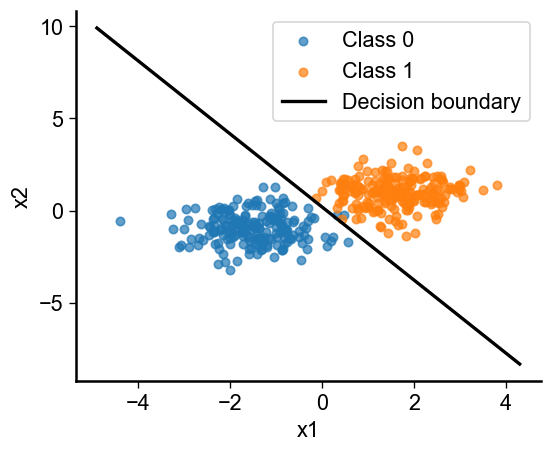

In [8]:
def make_separable_data(n_per_class=200, seed=SEED):
    rng = np.random.default_rng(seed)
    mean0 = np.array([-1.5, -1.0])
    mean1 = np.array([1.5, 1.0])
    cov = np.array([[0.6, 0.0], [0.0, 0.6]])
    X0 = rng.multivariate_normal(mean0, cov, size=n_per_class)
    X1 = rng.multivariate_normal(mean1, cov, size=n_per_class)
    X = np.vstack([X0, X1]).astype(np.float32)
    y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.float32)
    idx = rng.permutation(X.shape[0])
    return X[idx], y[idx]


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def bce_loss(y_hat, y):
    eps = 1e-12
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))


X_train, y_train = make_separable_data(n_per_class=200, seed=SEED)
X_test, y_test = make_separable_data(n_per_class=50, seed=SEED + 1)

w = np.zeros((2,), dtype=np.float32)
b = np.float32(0.0)

lr = 0.1
steps = 1000

for t in range(1, steps + 1):
    logits = X_train @ w + b
    y_hat = sigmoid(logits)
    # 梯度：dL/dlogits = (y_hat - y)
    grad_logits = (y_hat - y_train) / y_train.size
    grad_w = X_train.T @ grad_logits
    grad_b = np.sum(grad_logits)
    w -= lr * grad_w
    b -= lr * grad_b
    if t % 200 == 0 or t == 1:
        loss = bce_loss(y_hat, y_train)
        pred = (y_hat >= 0.5).astype(np.float32)
        acc = np.mean(pred == y_train)
        print(f'Step {t:04d}: loss={loss:.4f}, train acc={acc:.4f}')

test_probs = sigmoid(X_test @ w + b)
test_pred = (test_probs >= 0.5).astype(np.float32)
test_acc = np.mean(test_pred == y_test)
print('Test accuracy:', test_acc)

# 决策边界：w1*x + w2*y + b = 0
plt.figure(figsize=(5, 4))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], alpha=0.7, label='Class 0')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], alpha=0.7, label='Class 1')
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
xs = np.linspace(x_min, x_max, 200)
if abs(w[1]) > 1e-8:
    ys = -(w[0] * xs + b) / w[1]
    plt.plot(xs, ys, color='black', label='Decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()